# Bước 5: Huấn luyện mô hình XGBoost Classifier

Notebook này thực hiện huấn luyện mô hình **XGBoost Classifier** để dự đoán xếp hạng học lực (A-F) của sinh viên dựa trên tập dữ liệu đã được tiền xử lý.

## 1. Import thư viện

In [7]:
import os
import sys
import re
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

print("Imported necessary libraries successfully!")

Imported necessary libraries successfully!


## 2. Đọc dữ liệu thô và tiền xử lý đồng bộ với Backend

In [8]:
data_path = 'data/processed/Student_Performance_processed.csv'
for _ in range(5):
    if os.path.exists(data_path):
        break
    data_path = os.path.join('..', data_path)

df_encoded = pd.read_csv(data_path)

objective_features = [
    'age', 'study_hours', 'attendance_percentage',
    'math_score', 'science_score', 'english_score',
    'school_type', 'internet_access', 'extra_activities',
    'parent_education',
    'gender_male', 'gender_female', 'gender_other',
    'travel_time_<15 min', 'travel_time_15-30 min', 'travel_time_30-60 min', 'travel_time_>60 min',
    'study_method_notes', 'study_method_textbook', 'study_method_group study', 
    'study_method_coaching', 'study_method_mixed', 'study_method_online videos'
]

# Tạo Interaction Features giống như mô hình Random Forest
df_encoded['study_hours_x_attendance'] = df_encoded['study_hours'] * df_encoded['attendance_percentage']
df_encoded['study_hours_squared'] = df_encoded['study_hours'] ** 2
df_encoded['attendance_squared'] = df_encoded['attendance_percentage'] ** 2
objective_features += ['study_hours_x_attendance', 'study_hours_squared', 'attendance_squared']

# XGBoost không cho phép các ký tự đặc biệt như <, > trong tên cột, cần chuẩn hóa tên cột
sanitized_features = []
seen = {}
for col in objective_features:
    s = re.sub(r'[^0-9a-zA-Z_]', '_', col)
    if s in seen:
        seen[s] += 1
        s = f"{s}_{seen[s]}"
    else:
        seen[s] = 0
    sanitized_features.append(s)

mapping = dict(zip(objective_features, sanitized_features))
df_encoded = df_encoded.rename(columns=mapping)
X_features = df_encoded[sanitized_features]

print(f"Loaded processed data: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns.")
print(f"Feature count: {len(sanitized_features)}")

# Nhãn mục tiêu (A-F)
target = df_encoded['final_grade']
print("Target distribution:")
print(target.value_counts().sort_index())

Loaded processed data: 25000 rows, 29 columns.
Feature count: 26
Target distribution:
final_grade
a    1205
b    2696
c    6161
d    6311
e    5672
f    2955
Name: count, dtype: int64


## 3. Mã hóa nhãn (Target Encoding) và chia tập dữ liệu

In [9]:
# Encode target labels to integers for XGBoost
label_encoder = LabelEncoder()
target_encoded = label_encoder.fit_transform(target)
num_class = len(label_encoder.classes_)

# Train/Test Split (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    target_encoded,
    test_size=0.2,
    random_state=42,
    stratify=target_encoded
)
print(f"Train set: {X_train.shape[0]} rows, Test set: {X_test.shape[0]} rows")

Train set: 20000 rows, Test set: 5000 rows


## 4. Huấn luyện mô hình và Tối ưu hóa siêu tham số (Hyperparameter Tuning)

In [10]:
# Khởi tạo mô hình
clf_xgb = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'max_depth': [3, 4, 5, 6],
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [3, 5, 10, 15],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [1, 2, 5, 10],
    'gamma': [0, 0.1, 0.5]
}

print("Hyperparameter Tuning with RandomizedSearchCV...")
search_cv = RandomizedSearchCV(
    estimator=clf_xgb,
    param_distributions=param_grid,
    n_iter=15,  # Thử 15 tổ hợp cho nhanh trên notebook
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_cv.fit(X_train, y_train)
selected_model = search_cv.best_estimator_

print(f"\nBest Parameters: {search_cv.best_params_}")
print(f"Best CV Score (F1-Macro): {search_cv.best_score_:.4f}")

Hyperparameter Tuning with RandomizedSearchCV...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best Parameters: {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.9}
Best CV Score (F1-Macro): 0.8122


## 5. Đánh giá mô hình

Test Accuracy: 81.32%

Classification Report:
              precision    recall  f1-score   support

           a       0.81      0.79      0.80       241
           b       0.74      0.74      0.74       539
           c       0.83      0.82      0.82      1232
           d       0.80      0.82      0.81      1262
           e       0.83      0.81      0.82      1135
           f       0.84      0.86      0.85       591

    accuracy                           0.81      5000
   macro avg       0.81      0.81      0.81      5000
weighted avg       0.81      0.81      0.81      5000



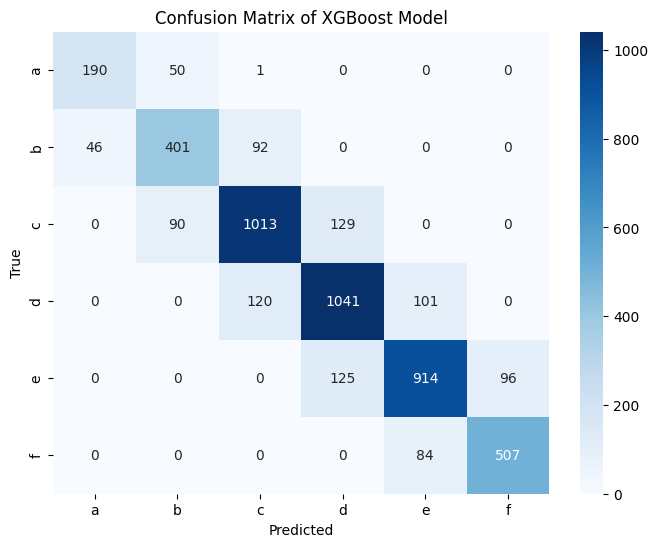

In [11]:
# Dự đoán trên tập test
y_pred = selected_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")

target_labels = list(label_encoder.classes_)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_labels))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=target_labels, 
    yticklabels=target_labels
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix of XGBoost Model")
plt.show()

## 6. Kiểm tra Overfitting

In [12]:
y_train_pred = selected_model.predict(X_train)
f1_train = f1_score(y_train, y_train_pred, average='macro')
f1_test = f1_score(y_test, y_pred, average='macro')

print("Overfitting Check")
print(f"Macro-F1 Train : {f1_train:.4f}")
print(f"Macro-F1 Test  : {f1_test:.4f}")
print(f"Difference     : {f1_train-f1_test:.4f}")

if f1_train - f1_test > 0.10:
    print("Warning: Overfitting detected")
else:
    print("Model is stable")

Overfitting Check
Macro-F1 Train : 0.8831
Macro-F1 Test  : 0.8075
Difference     : 0.0755
Model is stable
